# Experiments

This file contains multiple experiments that were done in order to find the solution to the [task](../task.md). Most of the necesary code is located in [solution.py](solution.py).

In [2]:
# %pip install numpy
# %pip install pandas
# %pip install torch torchvision--index-url https://download.pytorch.org/whl/cu121

In [1]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import solution
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import KFold

from solution import read_trainset, NetConfig, NeuralNetwork

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available(): print(f"Device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu126
CUDA available: True
Device: NVIDIA GeForce RTX 3060 Ti


## Method of evaluation
In order to make sure that the following experiments are reliable we used cross-validation for measuring prediction quality and accuracy. The accuracy itself is measured just like in the [helpers.py](../helpers.py) file provided.

In [2]:
NUM_CLASSES = 50

def calc_macro_accuracy(predictions: np.ndarray, targets: np.ndarray, n_classes: int = 50):
    assert len(predictions) == len(targets)
    accuracies = []
    for class_idx in range(n_classes):
        mask = targets == class_idx
        n_samples = mask.sum()
        if n_samples > 0:
            accuracies.append((predictions[mask] == class_idx).sum() / n_samples)
        else:
            accuracies.append(0.0)
    return float(np.mean(accuracies))


def make_dataloader(dataset, batch_size: int, shuffle: bool):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=4,
        pin_memory=torch.cuda.is_available(),
        prefetch_factor=2,
        persistent_workers=True,
    )


def evaluate_cross_validation(experiment_name, model_instance, full_dataset, number_of_folds: int = 3):
    kfold = KFold(n_splits=number_of_folds, shuffle=True, random_state=42)
    dataset_indices = np.arange(len(full_dataset))
    accuracy_scores = []

    initial_state = copy.deepcopy(model_instance.model.state_dict())

    for fold_number, (train_indices, validation_indices) in enumerate(kfold.split(dataset_indices), start=1):
        model_copy = copy.deepcopy(model_instance)
        model_copy.model.load_state_dict(initial_state)

        train_subset = Subset(full_dataset, train_indices)
        validation_subset = Subset(full_dataset, validation_indices)

        train_dataloader = make_dataloader(train_subset, batch_size=model_copy.config.batch_size, shuffle=True)
        validation_dataloader = make_dataloader(validation_subset, batch_size=model_copy.config.batch_size, shuffle=False)

        model_copy.fit(train_dataloader, print_epochs=False)
        predictions = np.array([prediction for _, prediction in model_copy.predict(validation_dataloader)])
        true_labels = np.array([full_dataset.targets[i] for i in validation_indices])

        fold_accuracy = calc_macro_accuracy(predictions, true_labels, n_classes=NUM_CLASSES)
        accuracy_scores.append(fold_accuracy)

    mean_accuracy = float(np.mean(accuracy_scores))
    std_accuracy = float(np.std(accuracy_scores))

    return {
        "experiment": experiment_name,
        "mean_macro_accuracy": mean_accuracy,
        "std_macro_accuracy": std_accuracy,
        "folds": number_of_folds,
        "epochs": model_instance.config.epochs,
        "batch_size": model_instance.config.batch_size,
        "learning_rate": model_instance.config.learning_rate,
        "batch_norm": model_instance.config.use_batch_normalization,
        "conv_layers": str(model_instance.config.convolutional_layers),
        "fc_layers": str(model_instance.config.fully_connected_layers),
        "dropout": str(model_instance.config.dropout_rates),
        "activation": str(model_instance.config.activation_types),
    }


def compare_models(experiments, training_data, number_of_folds: int = 3, model_factory=None):
    results = []
    for experiment_name, config in experiments:
        model = model_factory(config) if model_factory is not None else NeuralNetwork(config, num_classes=NUM_CLASSES)
        result = evaluate_cross_validation(
            experiment_name=experiment_name,
            model_instance=model,
            full_dataset=training_data,
            number_of_folds=number_of_folds,
        )
        results.append(result)

    return pd.DataFrame(results).sort_values(by="mean_macro_accuracy", ascending=False).reset_index(drop=True)

## Experiments

Reading in data with different image sizes and different augmentation configurations. They will be later on used to compare their influence on model's performance and accuracy.

In [3]:
_, train_data_default = read_trainset(augmentation="none", img_size=64)
_, train_data_weak = read_trainset(augmentation="weak", img_size=64)
_, train_data_strong = read_trainset(augmentation="strong", img_size=64)

_, train_data_96 = read_trainset(augmentation="weak", img_size=96)
_, train_data_128 = read_trainset(augmentation="weak", img_size=128)

NUM_CLASSES = len(train_data_default.classes)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Train size: {len(train_data_default)}")

Number of classes: 50
Train size: 88011


### Image size


In [4]:
def make_model_for_img_size(img_size: int):
    def _factory(config: NetConfig):
        old_img_size = solution.IMG_SIZE
        solution.IMG_SIZE = img_size
        try:
            return NeuralNetwork(config, num_classes=NUM_CLASSES)
        finally:
            solution.IMG_SIZE = old_img_size
    return _factory

In [ ]:
image_size_experiments = [
    ("IMG_SIZE = 64", 64, NetConfig(epochs=25, batch_size=64, learning_rate=3e-4)),
    ("IMG_SIZE = 96", 96, NetConfig(epochs=25, batch_size=64, learning_rate=3e-4)),
    ("IMG_SIZE = 128", 128, NetConfig(epochs=25, batch_size=64, learning_rate=3e-4)),
]

image_size_result_frames = []
for experiment_name, img_size, config in image_size_experiments:
    if img_size == 64:    dataset = train_data_weak
    elif img_size == 96:  dataset = train_data_96
    elif img_size == 128: dataset = train_data_128
    else:                 raise ValueError(f"Unsupported image size: {img_size}")

    result_df = compare_models( [(experiment_name, config)], training_data=dataset,  model_factory=make_model_for_img_size(img_size), number_of_folds=4)
    result_df["img_size"] = img_size
    image_size_result_frames.append(result_df)

pd.concat(image_size_result_frames, ignore_index=True).sort_values(by="mean_macro_accuracy", ascending=False).reset_index(drop=True)

All three image sizes produced very similar accuracy (around 0.59–0.60), suggesting that the model's performance is not particularly sensitive to input resolution in this range. Using smaller image resolutions should however, reduce the amount of time necesary to train the model.

### Augmentation


We compared three setups: *no augmentation*, *weak augmentation* (random horizontal flip only) *and strong augmentation* (horizontal flip, color jitter, slight rotation, and random crop).

In [ ]:
augmentation_experiments = [
    ("No augmentation", NetConfig(epochs=25, batch_size=64, learning_rate=3e-4)),
    ("Weak augmentation", NetConfig(epochs=25, batch_size=64, learning_rate=3e-4)),
    ("Strong augmentation", NetConfig(epochs=25, batch_size=64, learning_rate=3e-4)),
]

pd.concat([
    compare_models([augmentation_experiments[0]], training_data=train_data_default, number_of_folds=4 ),
    compare_models([augmentation_experiments[1]], training_data=train_data_weak,    number_of_folds=4 ),
    compare_models([augmentation_experiments[2]], training_data=train_data_strong,  number_of_folds=4 ),
], ignore_index=True).sort_values(by="mean_macro_accuracy", ascending=False).reset_index(drop=True)

,experiment,mean_macro_accuracy,std_macro_accuracy,folds,epochs,batch_size,learning_rate,batch_norm,conv_layers,fc_layers,dropout,activation
0,Strong augmentation,0.602956,0.007032,4,25,64,0.0003,True,"[32, 64, 128, 256]","[512, 128]",[0.2],[<class 'torch.nn.modules.activation.ReLU'>]
1,Weak augmentation,0.602725,0.005841,4,25,64,0.0003,True,"[32, 64, 128, 256]","[512, 128]",[0.2],[<class 'torch.nn.modules.activation.ReLU'>]
2,No augmentation,0.545977,0.003913,4,25,64,0.0003,True,"[32, 64, 128, 256]","[512, 128]",[0.2],[<class 'torch.nn.modules.activation.ReLU'>]


Adding **augmentation clearly helped**, both weak and strong versions boosted accuracy by about 10% compared to no augmentation at all.

### Batch Normalization & Batch sizes

Batch normalization helps stabilize training by normalizing layer outputs, while batch size controls how often the model updates its weights.

In [7]:
bn_batch_experiments = [
    ("No BN + Batch=32",  NetConfig(use_batch_normalization=False, batch_size=32,  epochs=20, learning_rate=3e-4)),
    ("No BN + Batch=64",  NetConfig(use_batch_normalization=False, batch_size=64,  epochs=20, learning_rate=3e-4)),
    ("No BN + Batch=128", NetConfig(use_batch_normalization=False, batch_size=128, epochs=20, learning_rate=3e-4)),
    ("BN + Batch=32",     NetConfig(use_batch_normalization=True,  batch_size=32,  epochs=20, learning_rate=3e-4)),
    ("BN + Batch=64",     NetConfig(use_batch_normalization=True,  batch_size=64,  epochs=20, learning_rate=3e-4)),
    ("BN + Batch=128",    NetConfig(use_batch_normalization=True,  batch_size=128, epochs=20, learning_rate=3e-4)),
]

compare_models(bn_batch_experiments, training_data=train_data_weak)

,experiment,mean_macro_accuracy,std_macro_accuracy,folds,epochs,batch_size,learning_rate,batch_norm,conv_layers,fc_layers,dropout,activation
0,BN + Batch=32,0.601271,0.001430,3,20,32,0.0003,True,"[32, 64, 128, 256]","[512, 128]",[0.2],[<class 'torch.nn.modules.activation.ReLU'>]
1,BN + Batch=64,0.594257,0.000773,3,20,64,0.0003,True,"[32, 64, 128, 256]","[512, 128]",[0.2],[<class 'torch.nn.modules.activation.ReLU'>]
2,BN + Batch=128,0.576822,0.001518,3,20,128,0.0003,True,"[32, 64, 128, 256]","[512, 128]",[0.2],[<class 'torch.nn.modules.activation.ReLU'>]
3,No BN + Batch=32,0.555715,0.001812,3,20,32,0.0003,False,"[32, 64, 128, 256]","[512, 128]",[0.2],[<class 'torch.nn.modules.activation.ReLU'>]
4,No BN + Batch=64,0.553093,0.005302,3,20,64,0.0003,False,"[32, 64, 128, 256]","[512, 128]",[0.2],[<class 'torch.nn.modules.activation.ReLU'>]
5,No BN + Batch=128,0.541272,0.005424,3,20,128,0.0003,False,"[32, 64, 128, 256]","[512, 128]",[0.2],[<class 'torch.nn.modules.activation.ReLU'>]


We can observe that all the models with **batch normalization outperformed** the other ones. Larger batch sizes hurt accuracy in both settings, which suggests the model learns better when weights are updated more often.

### Net layers and depth

We tested six network configurations ranging from *Tiny* to *Very Deep*, changing the number of convolutional layers and fully connected layers to see how network depth and layers configuration affects accuracy. *Conv layers* should extract features from the image and *fully connected layers* are supposed to turn those features into a final prediction.

In [ ]:
layer_experiments = [
        (
            "Tiny",
            NetConfig(
                convolutional_layers=[32],
                fully_connected_layers=[128],
                dropout_rates=[0.2],
                epochs=20,
                batch_size=32,
                learning_rate=3e-4,
            )
        ),
       (
        "Shallow",
        NetConfig(
            convolutional_layers=[32, 64],
            fully_connected_layers=[256],
            dropout_rates=[0.2],
            epochs=25,
            batch_size=32,
            learning_rate=3e-4,
        )
    ),
    (
        "Medium",
        NetConfig(
            convolutional_layers=[32, 64, 128],
            fully_connected_layers=[512, 128],
            dropout_rates=[0.2],
            epochs=25,
            batch_size=32,
            learning_rate=3e-4,
        )
    ),
    (
        "Deep",
        NetConfig(
            convolutional_layers=[32, 64, 128, 256],
            fully_connected_layers=[512, 256, 128],
            dropout_rates=[0.2],
            epochs=25,
            batch_size=32,
            learning_rate=3e-4,
        )
    ),
    (
        "Wide Deep",
        NetConfig(
            convolutional_layers=[32, 64, 128, 256, 256],
            fully_connected_layers=[1024, 512, 256],
            dropout_rates=[0.25],
            epochs=20,
            batch_size=32,
            learning_rate=3e-4,
        )
    ),
    (
    "Very Deep",
    NetConfig(
        convolutional_layers=[32, 64, 128, 256, 512],
        fully_connected_layers=[1024, 512, 256, 128],
        dropout_rates=[0.3], 
        epochs=25,
        batch_size=32,
        learning_rate=3e-4,
    )
), 

]

compare_models(layer_experiments, training_data=train_data_weak)

,experiment,mean_macro_accuracy,std_macro_accuracy,folds,epochs,batch_size,learning_rate,batch_norm,conv_layers,fc_layers,dropout,activation
0,Wide Deep,0.601728,0.001184,3,20,32,0.0003,True,"[32, 64, 128, 256, 256]","[1024, 512, 256]",[0.25],[<class 'torch.nn.modules.activation.ReLU'>]
1,Deep,0.598229,0.006154,3,25,32,0.0003,True,"[32, 64, 128, 256]","[512, 256, 128]",[0.2],[<class 'torch.nn.modules.activation.ReLU'>]
2,Very Deep,0.594210,0.002817,3,25,32,0.0003,True,"[32, 64, 128, 256, 512]","[1024, 512, 256, 128]",[0.3],[<class 'torch.nn.modules.activation.ReLU'>]
3,Medium,0.553807,0.000904,3,25,32,0.0003,True,"[32, 64, 128]","[512, 128]",[0.2],[<class 'torch.nn.modules.activation.ReLU'>]
4,Shallow,0.444600,0.005340,3,25,32,0.0003,True,"[32, 64]",[256],[0.2],[<class 'torch.nn.modules.activation.ReLU'>]
5,Tiny,0.386875,0.001114,3,20,32,0.0003,True,[32],[128],[0.2],[<class 'torch.nn.modules.activation.ReLU'>]


More layers generally improved accuracy, but *Very Deep* actually scored slightly worse than *Wide Deep*. This suggests that just adding more layers stops helping at some point and wider layers matter too.

### Optimizer + Weight Decay

We have tested 3 optimizers with proper weight decay: ADAM, ADAMW and SGD.

In [ ]:
base_params = {
    "epochs": 25,
    "batch_size":32,
    "convolutional_layers": [32, 64, 128, 256, 256],
    "fully_connected_layers": [1024, 512, 256],
    "use_batch_normalization": True,
    "dropout_rates": [0.25]
}

opt_experiments = [
    ("Adam_WD_small", NetConfig(**base_params, learning_rate=0.0003,  optimizer_type="Adam", weight_decay=1e-4)),
    ("AdamW_WD_small", NetConfig(**base_params, learning_rate=0.0003,  optimizer_type="AdamW", weight_decay=1e-4)),
    ("SGD_Momentum", NetConfig(**base_params, learning_rate=0.01, optimizer_type="SGD", weight_decay=1e-4, momentum=0.9))
]

final_results = []

for name, config in opt_experiments:
    print(f"Experiment: {name}...")
    
    model_inst = NeuralNetwork(config)
    

    res = evaluate_cross_validation(name, model_inst, train_data_weak, number_of_folds=5)
    
    final_results.append(res)

df_comparison = pd.DataFrame(final_results)
df_comparison = df_comparison.sort_values(by="mean_macro_accuracy", ascending=False)
display(df_comparison[["experiment", "mean_macro_accuracy", "std_macro_accuracy"]])

![Zrzut ekranu 2026-04-19 135921.png](<attachment:Zrzut ekranu 2026-04-19 135921.png>)
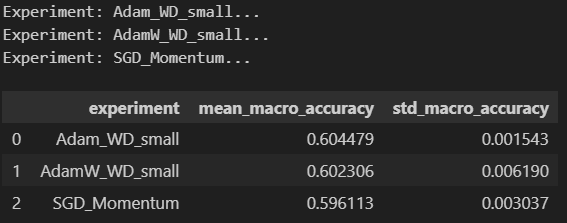

Adding extra optimizer does not have significant impact on accuracy. We will stick with Adam optimizer as it has the best results in our case, with which we will continue.

### Learning rate + scheduler
We have tested 3 learning rates suitable to our network.

In [ ]:
base_params = {
    "epochs": 40,
    "batch_size": 64,
    "convolutional_layers": [32, 64, 128, 256, 256],
    "fully_connected_layers": [1024, 512, 256],
    "use_batch_normalization": True,
    "dropout_rates": [0.25],
    "optimizer_type": "Adam", 
    "weight_decay": 1e-4
}

lr_values = [1e-3, 3e-4, 1e-4]
lr_experiments = [
    (f"Adam_LR_{lr}", NetConfig(**base_params, learning_rate=lr))
    for lr in lr_values
]

final_results = []

for name, config in lr_experiments:
    print(f"Experiment: {name}...")
    
    model_inst = NeuralNetwork(config)
    
    res = evaluate_cross_validation(name, model_inst, train_data_weak, number_of_folds=5)
    
    final_results.append(res)
    
df_comparison = pd.DataFrame(final_results)
df_comparison = df_comparison.sort_values(by="mean_macro_accuracy", ascending=False)

print(df_comparison[["experiment", "mean_macro_accuracy", "std_macro_accuracy"]])

![Zrzut ekranu 2026-04-19 162905.png](<attachment:Zrzut ekranu 2026-04-19 162905.png>)
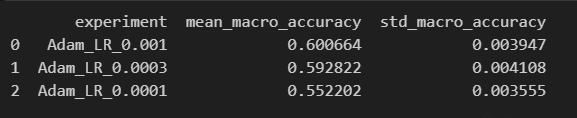

Changing learning rate did not give us almost any accuracy growth. The best result corresponds to learning rate of value 0.001.

### Final Grid search

Finally we have tested 8 combinations of hiperparameters.

In [ ]:
constant_params = {
    "epochs": 25,
    "batch_size": 64,
    "convolutional_layers": [32, 64, 128, 256],
    "learning_rate": 0.001,
    "optimizer_type": "Adam",
    "use_batch_normalization": True
}

grid = {
    "fully_connected_layers": [[512, 256], [256, 128]], 
    "dropout_rates": [[0.3], [0.5]],                   
    "weight_decay": [1e-4, 1e-5]                       
}

grid_experiments = []
for fc in grid["fully_connected_layers"]:
    for dropout in grid["dropout_rates"]:
        for wd in grid["weight_decay"]:
            name = f"FC_{fc[0]}_Drop_{dropout[0]}_WD_{wd}"
            config = NetConfig(**constant_params, 
                               fully_connected_layers=fc, 
                               dropout_rates=dropout, 
                               weight_decay=wd)
            grid_experiments.append((name, config))
            
final_results = []

for name, config in grid_experiments:
    print(f"Start: {name}...")
    
    model_inst = NeuralNetwork(config)
    
    res = evaluate_cross_validation(name, model_inst, train_data_weak, number_of_folds=5)
    
    final_results.append(res)


df_grid = pd.DataFrame(final_results)
df_grid = df_grid.sort_values(by="mean_macro_accuracy", ascending=False)

print("Configuration after grid search:")
display(df_grid[["experiment", "mean_macro_accuracy", "std_macro_accuracy"]])

![Zrzut ekranu 2026-04-19 195040.png](<attachment:Zrzut ekranu 2026-04-19 195040.png>)
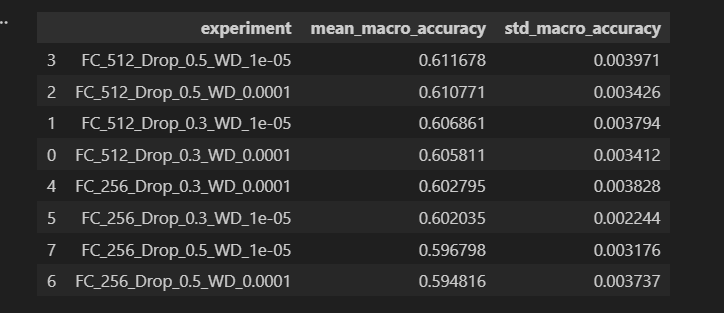

Grid search was the final attempt to improve our's network accuracy, however the additional income was not satisfying. The best result was for [512, 256] fully connected layers with additional 0.5 dropout and 1e-5 learning rate. These hiperparameter's values will be used in our final solution checked by test set.

## Conclusions
During these experiments we found that the best model configuration was:
- convolutional_layers: [32, 64, 128, 256]
- fully_connected_layers: [512, 128]
- dropout_rates: 0.5
- activation_types: ReLU
- use_batch_normalization: True
- batch_size: 64
- epochs: 25
- learning_rate: 1e-3
- optimizer_type: "Adam" 
- weight_decay: 1e-5
- momentum: 0.9
- nesterov: False


And that is the configuration we used to create our final predictions. We have tested our's network in many cases and all process took many hours. We have observed that changing optimizer as well as learning rate and other hiperparameters has minor impact on network accuracy comparing to network layers structures.


In [1]:
from solution import main

main()


--- Using GPU (NVIDIA GeForce RTX 4060 Laptop GPU) ---

[Step 1/4] Loading datasets...

[Step 2/4] Initializing and training the model...
	Epoch 1/25 - Loss: 2.7307, Accuracy: 25.13%
	Epoch 2/25 - Loss: 2.2294, Accuracy: 37.82%
	Epoch 3/25 - Loss: 2.0015, Accuracy: 44.22%
	Epoch 4/25 - Loss: 1.8227, Accuracy: 48.87%
	Epoch 5/25 - Loss: 1.6726, Accuracy: 52.98%
	Epoch 6/25 - Loss: 1.5364, Accuracy: 56.53%
	Epoch 7/25 - Loss: 1.4118, Accuracy: 59.97%
	Epoch 8/25 - Loss: 1.2915, Accuracy: 63.02%
	Epoch 9/25 - Loss: 1.1799, Accuracy: 65.86%
	Epoch 10/25 - Loss: 1.0733, Accuracy: 68.50%
	Epoch 11/25 - Loss: 0.9826, Accuracy: 71.09%
	Epoch 12/25 - Loss: 0.8964, Accuracy: 73.47%
	Epoch 13/25 - Loss: 0.8237, Accuracy: 75.24%
	Epoch 14/25 - Loss: 0.7584, Accuracy: 77.06%
	Epoch 15/25 - Loss: 0.7028, Accuracy: 78.94%
	Epoch 16/25 - Loss: 0.6490, Accuracy: 80.29%
	Epoch 17/25 - Loss: 0.6160, Accuracy: 81.09%
	Epoch 18/25 - Loss: 0.5705, Accuracy: 82.57%
	Epoch 19/25 - Loss: 0.5460, Accuracy: 83.